# Análisis y Visualización de Datos Clínicos con NumPy y Matplotlib

* **Módulo:** [3.1 Python — Fundamentos para análisis de datos](https://swcarpentry.github.io/python-novice-inflammation/) | **Fecha:** 11 de septiembre de 2026

> **Objetivo:** Implementar un flujo computacional de análisis y validación estadística sobre matrices de datos clínicos bidimensionales utilizando `numpy` y `matplotlib`, abordando gestión eficiente en memoria continua, agregación multieje, diagnóstico de anomalías numéricas y procesamiento automatizado por lotes.

## 1. Ingesta de Datos y Validación Estructural en Memoria
Se importan las dependencias del ecosistema científico (organizadas bajo PEP 8) y se carga la matriz de datos hacia un objeto `ndarray` contiguo en memoria RAM (C-order).

In [47]:
import matplotlib.pyplot as plt
import numpy as np

# Carga determinista de matriz delimitada por comas
data = np.loadtxt(fname='data/inflammation-01.csv', delimiter=',')

# Inspección de metadatos estructurales
print(f"Estructura de memoria: {type(data)}")
print(f"Dimensiones matriciales (filas, columnas): {data.shape}")
print(f"Tipo de dato numérico interno: {data.dtype}")
print(f"Total de observaciones escalares: {data.size}")

Estructura de memoria: <class 'numpy.ndarray'>
Dimensiones matriciales (filas, columnas): (60, 40)
Tipo de dato numérico interno: float64
Total de observaciones escalares: 2400


## 2. Particionamiento Matricial y Rebanado Bidimensional (Slicing 2D)
Se extraen registros puntuales y submatrices mediante indexación por coordenadas `[filas, columnas]`, considerando intervalos semiabiertos `[inicio:fin)` en base cero.

In [48]:
# Registro basal: Paciente 0, Día 0
print(f"Valor inicial (Paciente 0, Día 0): {data[0, 0]}")

# Registro medio: Paciente 30, Día 20
print(f"Valor en corte intermedio (Paciente 30, Día 20): {data[30, 20]}")

# Extracción de submatriz: Primeros 3 pacientes x Primeros 5 días
muestra_control = data[0:3, 0:5]
print("\nSubmatriz de control (3 pacientes x 5 días):")
print(muestra_control)

Valor inicial (Paciente 0, Día 0): 0.0
Valor en corte intermedio (Paciente 30, Día 20): 13.0

Submatriz de control (3 pacientes x 5 días):
[[0. 0. 1. 3. 1.]
 [0. 1. 2. 1. 2.]
 [0. 1. 1. 3. 3.]]


## 3. Agregación Estadística Multieje (Modelado `axis=0` vs `axis=1`)
Se evalúan las propiedades estadísticas colapsando dimensiones ortogonales:
* **`axis=0` (colapso vertical de filas):** Consolida los 60 pacientes para calcular métricas por cada uno de los **40 días**.
* **`axis=1` (colapso horizontal de columnas):** Consolida los 40 días para cuantificar el comportamiento acumulado de cada uno de los **60 pacientes**.

In [49]:
# Métricas longitudinales diarias (axis=0)
promedio_diario = np.mean(data, axis=0)
maximo_diario = np.max(data, axis=0)
minimo_diario = np.min(data, axis=0)
dispersion_diaria = np.std(data, axis=0)

print(f"Vectores diarios calculados — Dimensión: {promedio_diario.shape[0]} valores")
print(f"Rango global observado: Mínimo = {minimo_diario.min():.1f} | Máximo = {maximo_diario.max():.1f}")

# Métricas transversales por paciente (axis=1)
promedio_pacientes = np.mean(data, axis=1)
print(f"Vector de promedios por paciente — Dimensión: {promedio_pacientes.shape[0]} valores")

Vectores diarios calculados — Dimensión: 40 valores
Rango global observado: Mínimo = 0.0 | Máximo = 20.0
Vector de promedios por paciente — Dimensión: 60 valores


## 4. Distribución Espacio-Temporal: Mapa de Calor (Heatmap)
Visualización integral de la matriz completa (2400 observaciones) para detectar patrones globales de propagación o concentración de inflamación.

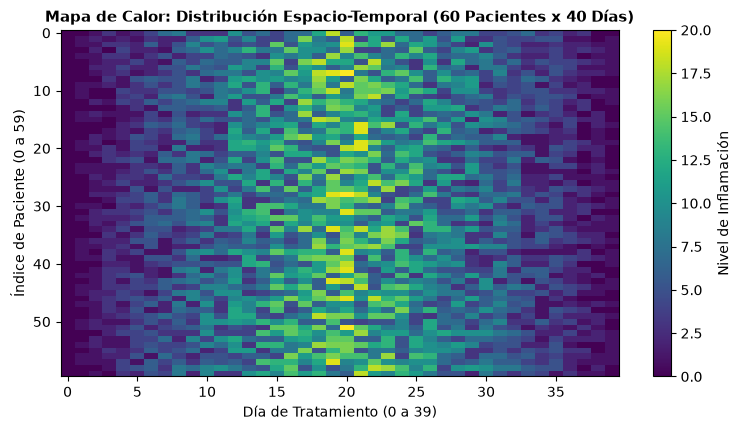

In [50]:
plt.figure(figsize=(9.0, 4.5))
plt.imshow(data, aspect='auto', cmap='viridis')
plt.colorbar(label='Nivel de Inflamación')
plt.title('Mapa de Calor: Distribución Espacio-Temporal (60 Pacientes x 40 Días)', fontsize=11, weight='bold')
plt.xlabel('Día de Tratamiento (0 a 39)', fontsize=10)
plt.ylabel('Índice de Paciente (0 a 59)', fontsize=10)
plt.show()

## 5. Dinámica Temporal y Perfiles de Extremos (Panel de Subplots)
Se construye un panel multivariable (1 fila $\times$ 3 columnas) para contrastar la tendencia central (media) frente a los límites extremos (máximos y mínimos). Se incorporan cuadrículas compuestas (mayor y menor) y marcadores para asegurar una lectura técnica rigurosa.

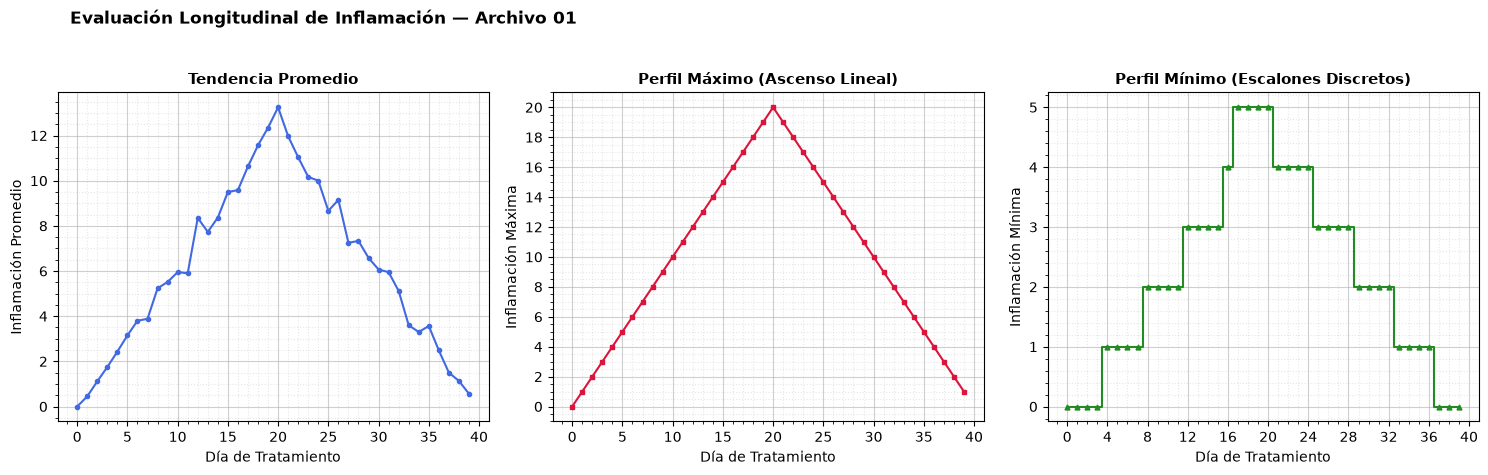

In [51]:
fig = plt.figure(figsize=(15.0, 4.8))
fig.suptitle('Evaluación Longitudinal de Inflamación — Archivo 01', x=0.05, y=0.98, ha='left', fontsize=12, weight='bold')

# 1. Subplot: Promedio Diario
ax1 = fig.add_subplot(1, 3, 1)
y1 = np.mean(data, axis=0)
ax1.plot(range(40), y1, linestyle='-', marker='o', markersize=3, color='royalblue')
ax1.set_title('Tendencia Promedio', fontsize=11, weight='bold')
ax1.set_xlabel('Día de Tratamiento', fontsize=10)
ax1.set_ylabel('Inflamación Promedio', fontsize=10)
ax1.set_xticks(np.arange(0, 41, 5))
ax1.minorticks_on()
ax1.grid(True, which='major', linestyle='-', alpha=0.6)
ax1.grid(True, which='minor', linestyle=':', alpha=0.3)

# 2. Subplot: Máximo Diario
ax2 = fig.add_subplot(1, 3, 2)
y2 = np.max(data, axis=0)
ax2.plot(range(40), y2, linestyle='-', marker='s', markersize=3, color='crimson')
ax2.set_title('Perfil Máximo (Ascenso Lineal)', fontsize=11, weight='bold')
ax2.set_xlabel('Día de Tratamiento', fontsize=10)
ax2.set_ylabel('Inflamación Máxima', fontsize=10)
ax2.set_xticks(np.arange(0, 41, 5))
ax2.set_yticks(np.arange(0, 21, 2))
ax2.minorticks_on()
ax2.grid(True, which='major', linestyle='-', alpha=0.6)
ax2.grid(True, which='minor', linestyle=':', alpha=0.3)

# 3. Subplot: Mínimo Diario
ax3 = fig.add_subplot(1, 3, 3)
y3 = np.min(data, axis=0)
ax3.step(range(40), y3, where='mid', color='forestgreen', linewidth=1.5)
ax3.plot(range(40), y3, linestyle='none', marker='^', markersize=3.5, color='forestgreen')
ax3.set_title('Perfil Mínimo (Escalones Discretos)', fontsize=11, weight='bold')
ax3.set_xlabel('Día de Tratamiento', fontsize=10)
ax3.set_ylabel('Inflamación Mínima', fontsize=10)
ax3.set_xticks(np.arange(0, 41, 4))
ax3.set_yticks(np.arange(0, 6, 1))
ax3.minorticks_on()
ax3.grid(True, which='major', linestyle='-', alpha=0.6)
ax3.grid(True, which='minor', linestyle=':', alpha=0.3)

fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 6. Pipeline Modular de Auditoría y Diagnóstico Algorítmico
Se encapsula el proceso en funciones modulares reutilizables con docstrings normalizados (PEP 257) para evaluar datasets de forma sistemática.

In [ ]:
def detectar_anomalias(data):
    """
    Audita la matriz de datos para detectar comportamientos matemáticos anómalos.

    Parámetros:
        data (np.ndarray): Matriz bidimensional de datos clínicos (pacientes x días).
    """
    max_diario = np.max(data, axis=0)
    min_diario = np.min(data, axis=0)

    # Condición 1: Rampa lineal artificial en máximos
    if max_diario[0] == 0 and max_diario[20] == 20:
        print('  ⚠️  ALERTA: Los valores máximos forman una rampa lineal artificial.')
    # Condición 2: Registros o sensores estáticos en cero
    elif np.sum(min_diario) == 0:
        print('  ⚠️  ALERTA: Los valores mínimos son cero todos los días (posible falla de sensor).')
    else:
        print('  ✅  COMPORTAMIENTO: Los datos parecen biológicamente naturales.')


def analizar(filename):
    """
    Carga un archivo CSV, ejecuta la detección de anomalías y genera el panel de subplots.

    Parámetros:
        filename (str): Ruta al archivo tabular CSV.
    """
    print(f"\n{'=' * 50}")
    print(f"AUDITORÍA CLÍNICA: {filename}")
    print(f"{'=' * 50}")

    data = np.loadtxt(fname=filename, delimiter=',')
    detectar_anomalias(data)

    fig = plt.figure(figsize=(15.0, 4.5))
    fig.suptitle(f'Estudio Clínico: {filename}', x=0.05, y=0.98, ha='left', fontsize=12, weight='bold')

    # Panel 1: Promedio
    ax1 = fig.add_subplot(1, 3, 1)
    y1 = np.mean(data, axis=0)
    ax1.plot(range(40), y1, linestyle='-', marker='o', markersize=3, color='royalblue')
    ax1.set_title('Promedio Diario', fontsize=10, weight='bold')
    ax1.set_xlabel('Día de Tratamiento', fontsize=9)
    ax1.set_ylabel('Inflamación', fontsize=9)
    ax1.minorticks_on()
    ax1.grid(True, which='major', linestyle='-', alpha=0.5)
    ax1.grid(True, which='minor', linestyle=':', alpha=0.25)

    # Panel 2: Máximo
    ax2 = fig.add_subplot(1, 3, 2)
    y2 = np.max(data, axis=0)
    ax2.plot(range(40), y2, linestyle='-', marker='s', markersize=3, color='crimson')
    ax2.set_title('Máximo Diario', fontsize=10, weight='bold')
    ax2.set_xlabel('Día de Tratamiento', fontsize=9)
    ax2.minorticks_on()
    ax2.grid(True, which='major', linestyle='-', alpha=0.5)
    ax2.grid(True, which='minor', linestyle=':', alpha=0.25)

    # Panel 3: Mínimo
    ax3 = fig.add_subplot(1, 3, 3)
    y3 = np.min(data, axis=0)
    ax3.step(range(40), y3, where='mid', color='forestgreen')
    ax3.plot(range(40), y3, linestyle='none', marker='^', markersize=3.5, color='forestgreen')
    ax3.set_title('Mínimo Diario', fontsize=10, weight='bold')
    ax3.set_xlabel('Día de Tratamiento', fontsize=9)
    ax3.minorticks_on()
    ax3.grid(True, which='major', linestyle='-', alpha=0.5)
    ax3.grid(True, which='minor', linestyle=':', alpha=0.25)

    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

## 7. Automatización por Lotes y Escalabilidad (`glob`)
Se automatiza la localización y procesamiento de colecciones de archivos mediante coincidencia de patrones y ordenamiento lexicográfico.

Total de archivos detectados en lote: 12

AUDITORÍA CLÍNICA: data\inflammation-01.csv
  ⚠️  ALERTA: Los valores máximos forman una rampa lineal artificial.


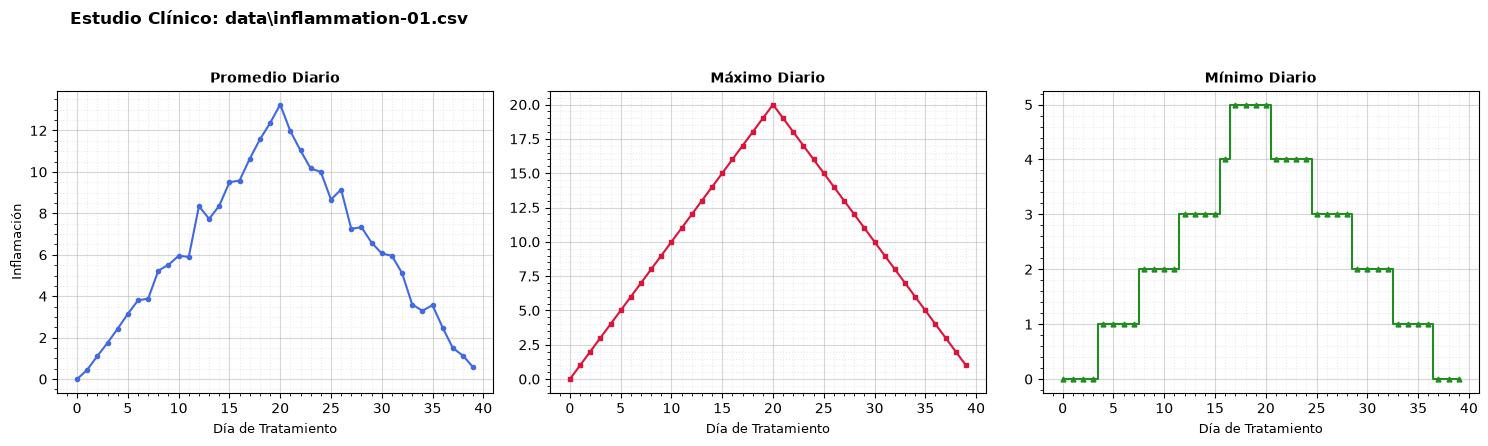


AUDITORÍA CLÍNICA: data\inflammation-02.csv
  ⚠️  ALERTA: Los valores máximos forman una rampa lineal artificial.


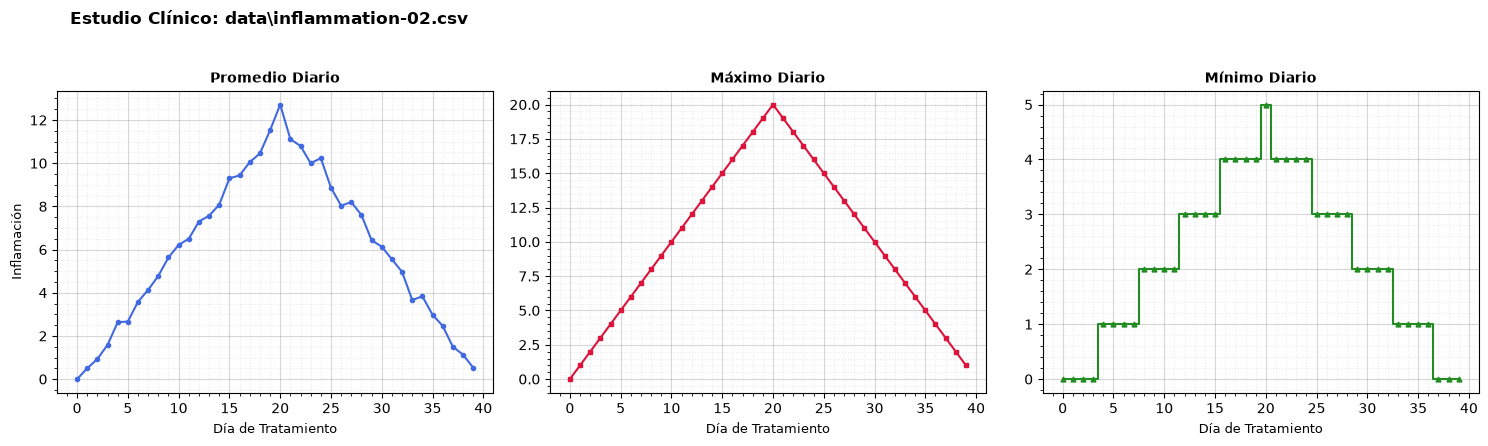


AUDITORÍA CLÍNICA: data\inflammation-03.csv
  ⚠️  ALERTA: Los valores mínimos son cero todos los días (posible falla de sensor).


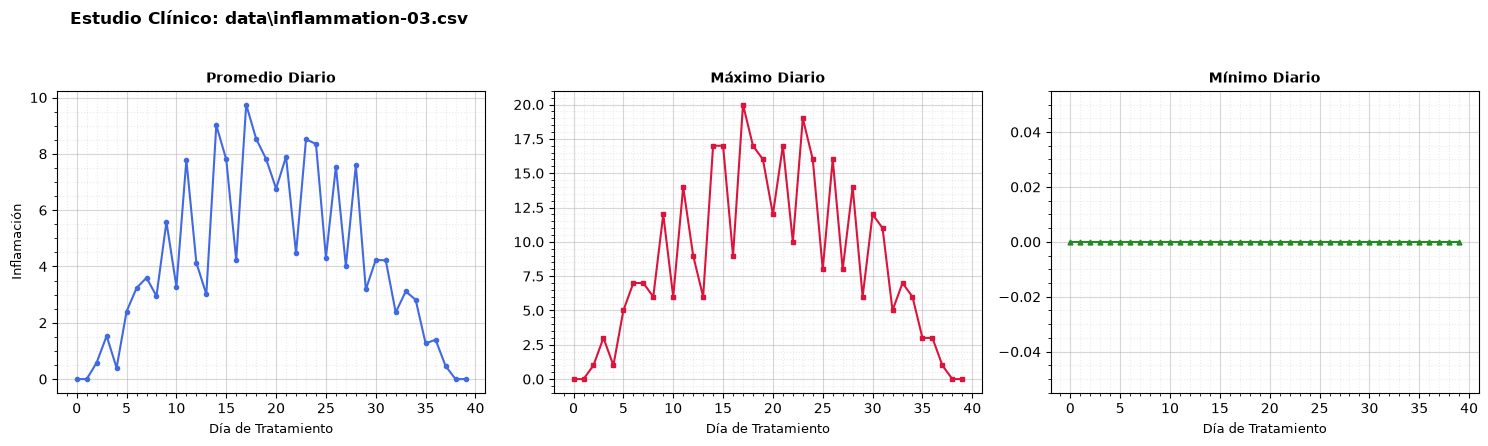

In [53]:
import glob

# Identificación determinista de archivos de datos
archivos_dataset = sorted(glob.glob('data/inflammation-*.csv'))
print(f"Total de archivos detectados en lote: {len(archivos_dataset)}")

# Ejecución en lote sobre muestra representativa (archivos 01 a 03)
for ruta in archivos_dataset[:3]:
    analizar(ruta)

## 8. Verificación Numérica de Linealidad con `np.diff()`
Para sustituir heurísticas empíricas dependientes de valores puntuales, se calcula la derivada discreta (tasa de cambio interdiaria) para determinar formalmente si el ascenso de máximos corresponde a una función matemática estricta.

In [54]:
# Extracción de máximos del archivo 01
data_01 = np.loadtxt(fname='data/inflammation-01.csv', delimiter=',')
maximos_01 = np.max(data_01, axis=0)

# Cálculo de diferencias finitas hacia adelante (tasa de cambio interdiaria)
derivada_ascenso = np.diff(maximos_01[:21])
print(f"Tasa de cambio interdiaria (días 0 a 20):\n{derivada_ascenso}")

# Validación de constancia unitaria
es_rampa_matematica = np.all(derivada_ascenso == 1.0)
print(f"\n¿Pendiente estrictamente constante e idéntica a 1.0?: {es_rampa_matematica}")

Tasa de cambio interdiaria (días 0 a 20):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

¿Pendiente estrictamente constante e idéntica a 1.0?: True


## 9. Síntesis y Conclusiones Técnicas

1. **Eficiencia Computacional en Memoria:** El uso de arreglos continuos `ndarray` de NumPy asegura vectorización a nivel de hardware, superando la sobrecarga estructural y de punteros inherente a las listas nativas de Python.
2. **Dominio Matricial y Ejes de Operación:** La comprensión del mecanismo de colapso dimensional (`axis=0` para métricas temporales de grupo, `axis=1` para perfiles de pacientes) garantiza cálculos analíticos reproducibles y sin ambigüedad.
3. **Visualización de Precisión:** La integración de cuadrículas compuestas (`major`/`minor`), marcadores explícitos y escalones ortogonales (`step`) permite representar datos discretos con rigor de publicación técnica.
4. **Auditoría Forense de Datasets:** El análisis diferencial (`np.diff`) demostró que `inflammation-01.csv` e `inflammation-02.csv` contienen patrones lineales artificiales con derivada unitaria perfecta y escalones sintéticos de 4 días, mientras que `inflammation-03.csv` evidencia fallas de instrumentación por registros estáticos en cero absoluto.